<a href="https://colab.research.google.com/github/jesucristomicentrodemivida-ai/LABORATORIO-13-YAMI/blob/main/laboratorio4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Presentado por:
Yamile Garcia Alzate
Grupo Inteligencia Artificial


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entrenando el modelo, esto puede tardar unos segundos...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8790 - loss: 0.4324 - val_accuracy: 0.9597 - val_loss: 0.1312
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9667 - loss: 0.1129 - val_accuracy: 0.9718 - val_loss: 0.0916
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9769 - loss: 0.0765 - val_accuracy: 0.9718 - val_loss: 0.0865
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9840 - loss: 0.0537 - val_accuracy: 0.9758 - val_loss: 0.0744
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9883 - loss: 0.0395 - val_accuracy: 0.9751 - val_loss: 0.0827
313/313 - 1s - 2ms/step - accuracy: 0.9751 - loss: 0.0827

Precisión en las imágenes de prueba: 97.51%
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


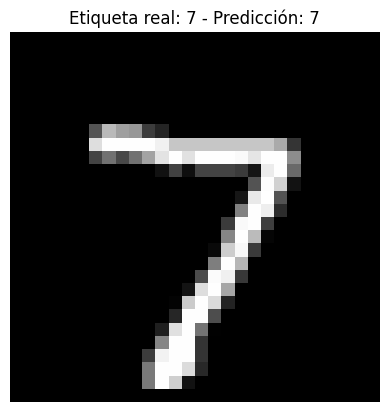

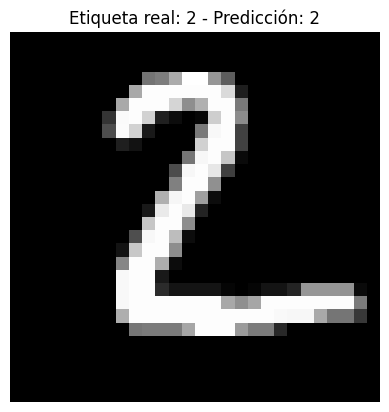

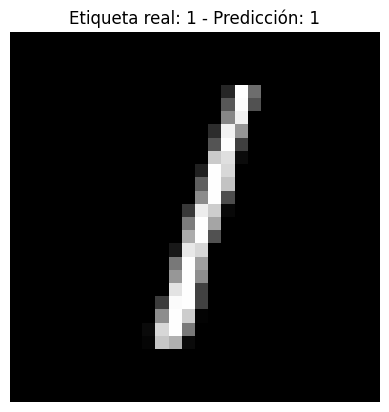

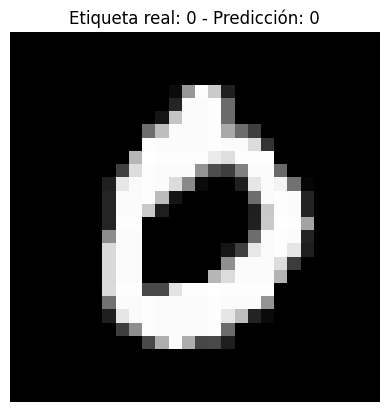

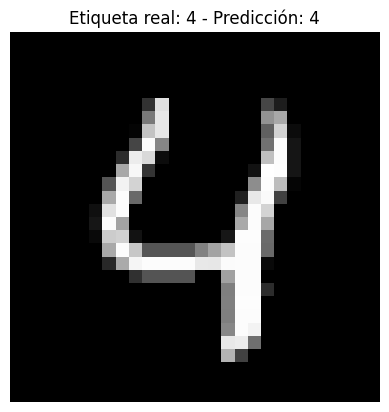

In [7]:
# Paso 1: Importar las librerías necesarias
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Paso 2: Cargar el conjunto de datos de imágenes (MNIST)
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Paso 3: Normalizar los valores de píxeles (de 0-255 a 0-1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Paso 4: Construir un modelo sencillo (aprendizaje supervisado)
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),  # Aplana la imagen a un vector
    layers.Dense(128, activation='relu'),  # Capa oculta con 128 neuronas
    layers.Dense(10, activation='softmax') # 10 salidas (dígitos 0 al 9)
])

# Paso 5: Compilar el modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Paso 6: Entrenar el modelo con los datos
print("Entrenando el modelo, esto puede tardar unos segundos...")
model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

# Paso 7: Evaluar el modelo
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nPrecisión en las imágenes de prueba: {test_acc*100:.2f}%")

# Paso 8: Mostrar algunas predicciones
predicciones = model.predict(X_test)

# Mostrar las primeras 5 imágenes con sus etiquetas reales y predichas
for i in range(5):
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Etiqueta real: {y_test[i]} - Predicción: {predicciones[i].argmax()}")
    plt.axis('off')
    plt.show()


No Supervisado

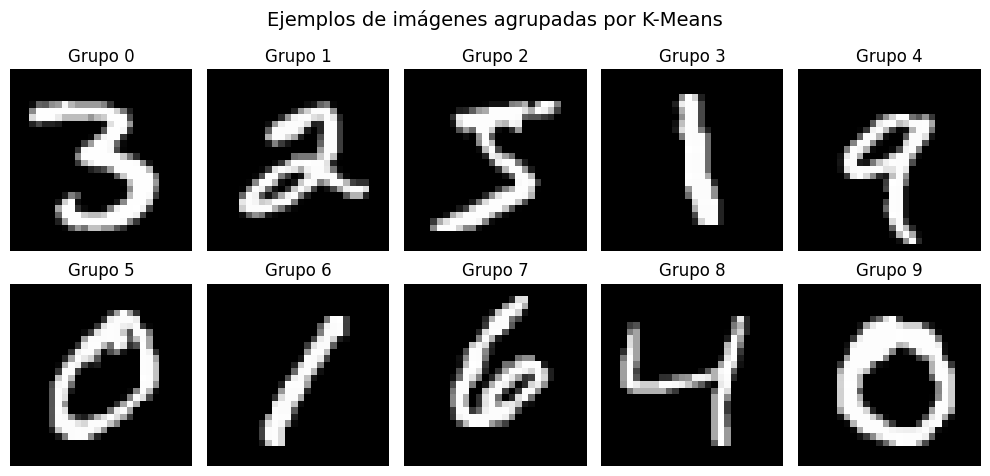

Grupo 0: 559 imágenes
Grupo 1: 396 imágenes
Grupo 2: 526 imágenes
Grupo 3: 715 imágenes
Grupo 4: 715 imágenes
Grupo 5: 272 imágenes
Grupo 6: 379 imágenes
Grupo 7: 437 imágenes
Grupo 8: 791 imágenes
Grupo 9: 210 imágenes


In [8]:
# Paso 1: Importar las librerías necesarias
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

# Paso 2: Cargar las imágenes (sin etiquetas)
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Solo usaremos una parte para hacerlo más rápido
X = X_train[:5000]

# Paso 3: Preprocesar las imágenes
# Convertir a vector (cada imagen 28x28 se convierte en un vector de 784 valores)
X_flat = X.reshape((X.shape[0], -1))

# Normalizar los valores (0 a 1)
X_flat = X_flat / 255.0

# Paso 4: Reducir la dimensionalidad con PCA (para hacerlo más rápido y visualizable)
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_flat)

# Paso 5: Aplicar K-Means para encontrar grupos (clusters)
kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# Paso 6: Mostrar algunas imágenes de cada grupo
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
fig.suptitle("Ejemplos de imágenes agrupadas por K-Means", fontsize=14)

for cluster_num, ax in enumerate(axes.flat):
    # Selecciona una imagen aleatoria de ese grupo
    idx = np.where(clusters == cluster_num)[0][0]
    ax.imshow(X[idx], cmap="gray")
    ax.set_title(f"Grupo {cluster_num}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Paso 7: (Opcional) Ver cuántas imágenes hay por grupo
unique, counts = np.unique(clusters, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Grupo {u}: {c} imágenes")
